# Machine Learning - Classificação 03
- treinamento dos modelos
- leitura de métricas

In [13]:
import pandas as pd
X = pd.read_csv("marketing_investimento_features.csv")
y = pd.read_csv("marketing_investimento_target.csv")
X.drop(columns = ["Unnamed: 0"], inplace = True)
y.drop(columns = ["Unnamed: 0"], inplace = True)

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   ID                                          1268 non-null   int64  
 1   onehotencoder__estado_civil_casado (a)      1268 non-null   float64
 2   onehotencoder__estado_civil_divorciado (a)  1268 non-null   float64
 3   onehotencoder__estado_civil_solteiro (a)    1268 non-null   float64
 4   onehotencoder__escolaridade_fundamental     1268 non-null   float64
 5   onehotencoder__escolaridade_medio           1268 non-null   float64
 6   onehotencoder__escolaridade_superior        1268 non-null   float64
 7   onehotencoder__inadimplencia_sim            1268 non-null   float64
 8   onehotencoder__fez_emprestimo_sim           1268 non-null   float64
 9   remainder__idade                            1268 non-null   float64
 10  remainder__s

Para entendermos se o modelo entendeu o padrão dos dados ou apenas decorou, vamos separar em:
- treino | teste

In [2]:
from sklearn.model_selection import train_test_split

- Para manter a mesma proporção do target no treino e teste, usamos o parametro **stratify**
- Random State seria a seed

In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify = y, random_state = 42)

- Total de linhas = 1.268
- _treino = 75%
- _teste = 25%

---
### Conceitos Importantes
1. **Overfitting** (Sobreajuste): Quando o modelo se adequa demais aos dados de treinamento, e tem baixo desempenho em dados de teste. Isso indica que o modelo capturou ruídos e variações aleatórias nos dados de treinamento. Ele acaba sendo muito bom com dados de treino, porém muito ruim com dados de teste.
- Erro muito baixo nas predições em dados de treinamento;
- Erro muito alto nas predições em dados de teste;
- Modelo muito complexo que tenta memorizar os dados de treinamento ao invés de aprender o padrão dos dados.

2. **Underfitting** (Subajuste): Quando o modelo é muito simples e não consegue identificar padrões presentes nos dados. Então ele não conseguiu apreender com os dados fornecidos.
- Erro muito alto nas predições em dados de treinamento;
- Erro muito alto nas predições em dados de teste;
- Modelo muito simples que não consegue representar bem os dados.

---

## Modelo de Base (Dummy)
Vamos utilizar um modelo simples para classificar os dados. Este modelo serve como critério de comparação para identificar se os outros modelos tem um melhor desempenho do que a classificação mais simples possivel, classificando com base no valor de maior frequência do target

In [4]:
from sklearn.dummy import DummyClassifier

In [15]:
dummy = DummyClassifier() #criando uma variavel com a classe do modelo
dummy.fit(X_treino, y_treino) # todos os modelos se treinam com fit

dummy.score(X_teste, y_teste)

0.6056782334384858

## Decision Forest
A arvoré faz comparações de valores que levam a tomadas de decisões.
Para definir os tresholds corretos existe um calculo da teoria da informação que será explicado em uma pasta especifica, que contem uma explicação detalhada e um código de Decision Forest em Sracth

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
arvore = DecisionTreeClassifier(random_state = 5)
arvore.fit(X_treino , y_treino)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
arvore.predict(X_teste)

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,

In [18]:
arvore.score(X_teste , y_teste)

0.6656151419558359

Já tivemos um resultado melhor que o Dummy, mas agora vamos ver as regras da arvore

Vamos plotar nosso algoritimo de árvore de decisão

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [22]:
colunas_lista = list()
for coluna in X.columns:
    colunas_lista.append(coluna)
    print(coluna, f"armazenada na lista. \nVolume atual {len(colunas_lista)}")

onehotencoder__estado_civil_casado (a) armazenada na lista. 
Volume atual 1
onehotencoder__estado_civil_divorciado (a) armazenada na lista. 
Volume atual 2
onehotencoder__estado_civil_solteiro (a) armazenada na lista. 
Volume atual 3
onehotencoder__escolaridade_fundamental armazenada na lista. 
Volume atual 4
onehotencoder__escolaridade_medio armazenada na lista. 
Volume atual 5
onehotencoder__escolaridade_superior armazenada na lista. 
Volume atual 6
onehotencoder__inadimplencia_sim armazenada na lista. 
Volume atual 7
onehotencoder__fez_emprestimo_sim armazenada na lista. 
Volume atual 8
remainder__idade armazenada na lista. 
Volume atual 9
remainder__saldo armazenada na lista. 
Volume atual 10
remainder__tempo_ult_contato armazenada na lista. 
Volume atual 11
remainder__numero_contatos armazenada na lista. 
Volume atual 12


[Text(0.5354640151515152, 0.9807692307692307, 'remainder__tempo_ult_contato <= 349.5\ngini = 0.479\nsamples = 951\nvalue = [574, 377]\nclass = Não Investiu'),
 Text(0.29375, 0.9423076923076923, 'remainder__tempo_ult_contato <= 212.5\ngini = 0.354\nsamples = 621\nvalue = [478, 143]\nclass = Não Investiu'),
 Text(0.41460700757575764, 0.9615384615384615, 'True  '),
 Text(0.10828598484848485, 0.9038461538461539, 'remainder__tempo_ult_contato <= 86.5\ngini = 0.24\nsamples = 408\nvalue = [351, 57]\nclass = Não Investiu'),
 Text(0.045454545454545456, 0.8653846153846154, 'onehotencoder__estado_civil_divorciado (a) <= 0.5\ngini = 0.056\nsamples = 138\nvalue = [134, 4]\nclass = Não Investiu'),
 Text(0.030303030303030304, 0.8269230769230769, 'remainder__idade <= 34.5\ngini = 0.031\nsamples = 125\nvalue = [123, 2]\nclass = Não Investiu'),
 Text(0.024242424242424242, 0.7884615384615384, 'remainder__idade <= 33.5\ngini = 0.091\nsamples = 42\nvalue = [40, 2]\nclass = Não Investiu'),
 Text(0.012121212

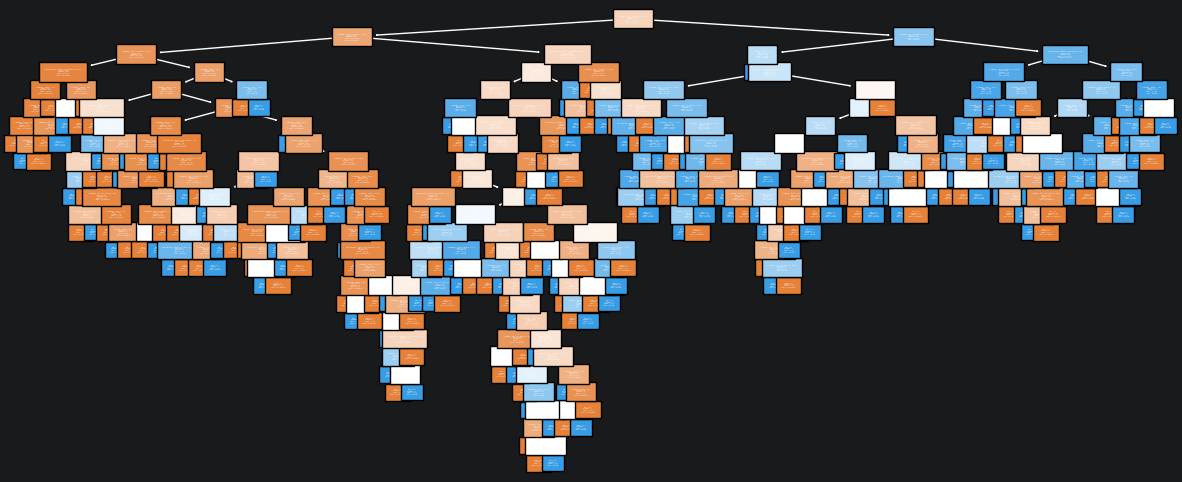

In [24]:
plt.figure(figsize = (15,6))
plot_tree(arvore, filled = True, class_names = ['Não Investiu', 'Investiu'], fontsize = 1, feature_names = colunas_lista)

In [25]:
arvore.score(X_treino, y_treino)

1.0

Nesse caso nosso modelo apenas decorou os resultados e criou regras que: são feitas especificamente para os datasets de treino

- **max_depth** define a profundidade máxima que uma árvore de decisão pode atingir. Quanto maior esse valor, mais divisões a árvore poderá realizar, tornando-se mais complexa e capaz de aprender padrões específicos dos dados. No entanto, árvores muito profundas podem sofrer overfitting, ajustando-se excessivamente aos dados de treino e perdendo capacidade de generalização. Por outro lado, valores muito baixos podem resultar em underfitting, fazendo com que a árvore seja simples demais

In [59]:
arvore = DecisionTreeClassifier(max_depth = 3, random_state = 42)
arvore.fit(X_treino, y_treino)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [60]:
print("Score de treino: ", arvore.score(X_treino, y_treino))
print("Score de teste: ", arvore.score(X_teste, y_teste))

Score de treino:  0.7486855941114616
Score de teste:  0.7129337539432177


[Text(0.5, 0.875, 'remainder__tempo_ult_contato <= 349.5\ngini = 0.479\nsamples = 951\nvalue = [574, 377]\nclass = Não Investiu'),
 Text(0.25, 0.625, 'remainder__tempo_ult_contato <= 212.5\ngini = 0.354\nsamples = 621\nvalue = [478, 143]\nclass = Não Investiu'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'remainder__tempo_ult_contato <= 86.5\ngini = 0.24\nsamples = 408\nvalue = [351, 57]\nclass = Não Investiu'),
 Text(0.0625, 0.125, 'gini = 0.056\nsamples = 138\nvalue = [134, 4]\nclass = Não Investiu'),
 Text(0.1875, 0.125, 'gini = 0.316\nsamples = 270\nvalue = [217, 53]\nclass = Não Investiu'),
 Text(0.375, 0.375, 'onehotencoder__escolaridade_fundamental <= 0.5\ngini = 0.481\nsamples = 213\nvalue = [127.0, 86.0]\nclass = Não Investiu'),
 Text(0.3125, 0.125, 'gini = 0.495\nsamples = 184\nvalue = [101, 83]\nclass = Não Investiu'),
 Text(0.4375, 0.125, 'gini = 0.185\nsamples = 29\nvalue = [26, 3]\nclass = Não Investiu'),
 Text(0.75, 0.625, 'remainder__tempo_ult_contato <= 631.5\ng

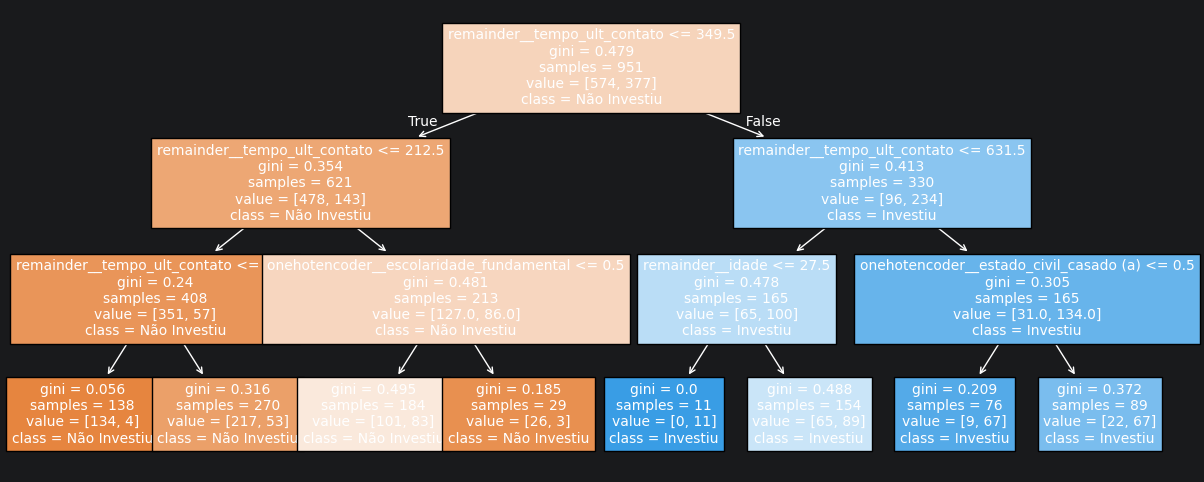

In [63]:
plt.figure(figsize = (15,6))
plot_tree(arvore, filled = True, class_names = ['Não Investiu', 'Investiu'], fontsize = 10, feature_names = colunas_lista)

Já melhoramos a taxa de acerto do nosso modelo removendo o nível de complexidade